In [1]:
%load_ext kedro.ipython

import numpy as np
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb
import matplotlib.pyplot as plt

random_state = catalog.load('params:model_options.random_state')
test_size = catalog.load('params:model_options.test_size')

[01/12/25 18:35:48] INFO     Using 'conf\logging.yml' as logging configuration. You can change this ]8;id=378909;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=250929;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\framework\project\__init__.py#270\270]8;;\
                             by setting the KEDRO_LOGGING_CONFIG environment variable accordingly.                 

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=603854;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=985685;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#61\61]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=717188;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=263194;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#63\63]8;;\

                    INFO     Resolved project path as: d:\UNIWERSYTET WARSZAWSKI\Machine Learning   ]8;id=539094;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=351831;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#178\178]8;;\
                             in Finance\II\Projects\ML_travel_insurance.                                           
                             To set a different path, run '%reload_kedro <project_root>'                           

[01/12/25 18:35:58] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=347531;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=508736;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro_telemetry\plugin.py#233\233]8;;\
                             the product. No personal data or IP addresses are stored on our side. If              
                             you want to opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK`              
                             environment variables, or create a `.telemetry` file in the current                   
                             working directory with the contents `consent: false`. Read more at                    
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

                    INFO     Kedro project ML_travel_insurance                                      ]8;id=934866;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=798435;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#144\144]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=454168;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=857607;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\ipython\__init__.py#145\145]8;;\
                             'pipelines'                                                                           

                    INFO     Loading data from params:model_options.random_state                ]8;id=508568;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=597375;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

                    INFO     Loading data from params:model_options.test_size                   ]8;id=76329;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=547454;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

In [2]:
X_train, y_train = catalog.load('TI_train_feature'), catalog.load('TI_y_train_feature')
X_test, y_test = catalog.load('TI_test_feature'), catalog.load('TI_y_test_feature')

X_train.columns = X_train.columns.str.replace(' ', '')
X_test.columns = X_test.columns.str.replace(' ', '')

                    INFO     Loading data from TI_train_feature (CSVDataset)...                 ]8;id=420497;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=478218;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

[01/12/25 18:35:59] INFO     Loading data from TI_y_train_feature (CSVDataset)...               ]8;id=446185;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=114347;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=641954;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=963668;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=887564;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=400370;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [3]:
gbmX_train, gbmX_val, gbmY_train, gbmY_val = train_test_split(
    X_train, y_train, test_size=test_size, random_state=random_state
)

weights = compute_sample_weight('balanced', gbmY_train)

train_data = lgb.Dataset(data=gbmX_train, label=gbmY_train, weight=weights)
val_data = lgb.Dataset(data=gbmX_val, label=gbmY_val, reference=train_data)

In [4]:
# param = {'num_leaves': 31, 'objective': 'binary'}
# param['metric'] = 'average_precision'

# num_round = 10
# bst = lgb.train(param, train_data, num_round, valid_sets=[val_data])

In [5]:
lgbm_trained = catalog.load('lgbm_trained')
best_model = lgbm_trained['final_model']
best_params = lgbm_trained['best_params']

best_params

                    INFO     Loading data from lgbm_trained (PickleDataset)...                  ]8;id=39327;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=698137;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\


{
    'learning_rate': 0.11085448948778212,
    'min_child_samples': 42,
    'n_estimators': 31,
    'num_leaves': 23,
    'reg_alpha': 1.4746910125599388,
    'reg_lambda': 1.7174044351540314
}

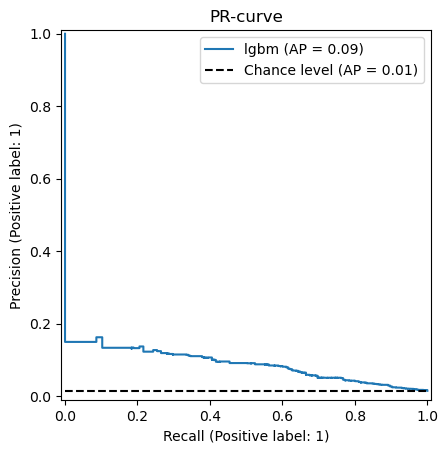

In [6]:
y_proba = best_model.predict_proba(X_test)

display = PrecisionRecallDisplay.from_predictions(
    y_test.T.values[0], y_proba[:, 1], name='lgbm', plot_chance_level=True
)
_ = display.ax_.set_title("PR-curve")
plt.legend()
plt.show()